# Accident Detection — SAM 3.1 + Physics Signals
**CVPR 2026 ACCIDENT Competition**

**Pipeline:**
1. SAM 3.1 (MLX) for open-vocabulary vehicle detection per frame
2. `crash_signals.py` — three fused signals:
   - **Signal 1** SORT-lite tracker + velocity drop (moving→stopped)
   - **Signal 2** Farneback optical flow anomaly in close-pair regions
   - **Signal 3** Trajectory projection + heading → collision type classifier
3. Crash declared when ≥2 signals agree within a 10-frame window
4. Render annotated video + score against GT

**Outputs:** `accident_time`, `center_x/y`, `collision_type`


## 1. Install Dependencies

In [1]:
import subprocess, sys
from pathlib import Path

# mlx-vlm 0.4.3 (sam3_1 support) is on GitHub main, not yet on PyPI
uv_bin = Path.home() / ".local" / "bin" / "uv"

packages = [
    "git+https://github.com/Blaizzy/mlx-vlm.git",  # 0.4.3+ with sam3_1
    "opencv-python-headless",
    "Pillow",
    "numpy",
    "matplotlib",
    "tqdm",
    "ipywidgets",
    "pandas",
]

for pkg in packages:
    result = subprocess.run(
        [str(uv_bin), "pip", "install", "--quiet", pkg],
        capture_output=True, text=True
    )
    label = "mlx-vlm@github" if "git+" in pkg else pkg
    status = "OK" if result.returncode == 0 else "FAILED"
    print(f"{status}: {label}")
    if result.returncode != 0:
        print(result.stderr)

print("\nAll dependencies installed.")


OK: mlx-vlm@github
OK: opencv-python-headless
OK: Pillow
OK: numpy
OK: matplotlib
OK: tqdm
OK: ipywidgets
OK: pandas

All dependencies installed.


## 2. Imports & Config

In [2]:
import cv2
import json
import gzip
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

# ── Paths ──────────────────────────────────────────────────────────────────────
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "test_metadata.csv").exists():
            return candidate
    return start.resolve()

ROOT        = find_project_root(Path.cwd())
SIM_DIR     = ROOT / "sim_dataset"
VIDEO_DIR   = SIM_DIR / "videos"
ANNOT_DIR   = SIM_DIR / "video_annotations"
OUTPUT_DIR  = ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Test clip ──────────────────────────────────────────────────────────────────
CLIP_NAME   = "Town03_head-on_clear_01"
CLIP_TYPE   = "head-on"
VIDEO_PATH  = VIDEO_DIR / CLIP_TYPE / f"{CLIP_NAME}.mp4"
ANNOT_PATH  = ANNOT_DIR / f"{CLIP_NAME}.json" / f"{CLIP_NAME}.json"

# ── SAM 3.1 model ─────────────────────────────────────────────────────────────
MODEL_ID    = "mlx-community/sam3.1-bf16"

# ── Detection config ──────────────────────────────────────────────────────────
# Two prompts covers cars + larger vehicles in CARLA; predict_multi batches them
VEHICLE_PROMPTS     = ["a car", "a truck"]
SCORE_THRESHOLD     = 0.15   # match reference notebook
NMS_IOU_THRESH      = 0.5    # suppress duplicate boxes
DETECT_EVERY        = 12     # ~0.6s cadence on 20fps
INFER_SIZE          = (960, 540)   # downscale for inference; boxes rescaled back
IOU_CRASH_THRESH    = 0.01
PROXIMITY_RATIO     = 0.15

print(f"Video : {VIDEO_PATH}")
print(f"Exists: {VIDEO_PATH.exists()}")
print(f"Inference resolution: {INFER_SIZE[0]}x{INFER_SIZE[1]}")
print(f"Detect every {DETECT_EVERY} frames  |  prompts: {VEHICLE_PROMPTS}")


Video : /Users/agirgis/Downloads/Kaggle/accidents_cvpr/sim_dataset/videos/head-on/Town03_head-on_clear_01.mp4
Exists: True
Inference resolution: 960x540
Detect every 12 frames  |  prompts: ['a car', 'a truck']


## 3. Load Ground-Truth Annotations

In [3]:
def load_annotation(path: Path) -> dict:
    """Load annotation JSON, supporting plain .json or .json.gz."""
    if str(path).endswith(".gz"):
        with gzip.open(path, "rt") as f:
            return json.load(f)
    with open(path) as f:
        return json.load(f)


ann = load_annotation(ANNOT_PATH)

# ── Ground-truth collision info ────────────────────────────────────────────────
gt_first_collision_iter = ann["collision"][0]["iteration"]
gt_collision_bbox       = ann["collision"][0]["collision_bbox"]   # [[x1,y1],[x2,y2]]
gt_colliding_ids        = ann["collision"][0]["ids"]

# Video metadata
cap = cv2.VideoCapture(str(VIDEO_PATH))
FPS    = cap.get(cv2.CAP_PROP_FPS)
W      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
NFRAMES= int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

# The annotation uses "iterations" that are offset from video frame 0.
# From labels.csv: annotations_start_offset tells us which video frame = iter 0.
# For this clip the offset is in the labels CSV; we derive it:
# iter_76 = first annotated frame → video frame index = 76 - offset
# We read it directly from the JSON: base[0].iteration gives us the first iter.
ANNOT_OFFSET = ann["base"][0]["iteration"]   # iterations start at 76

def iter_to_frame(iteration: int) -> int:
    """Convert simulation iteration to 0-based video frame index."""
    return iteration - ANNOT_OFFSET

gt_crash_frame = iter_to_frame(gt_first_collision_iter)
gt_crash_time  = gt_crash_frame / FPS

# Normalised crash centre (for submission)
(x1, y1), (x2, y2) = gt_collision_bbox
gt_cx = ((x1 + x2) / 2) / W
gt_cy = ((y1 + y2) / 2) / H

print(f"Video     : {W}x{H} @ {FPS:.0f}fps, {NFRAMES} frames ({NFRAMES/FPS:.2f}s)")
print(f"GT crash  : iteration {gt_first_collision_iter} → frame {gt_crash_frame} → {gt_crash_time:.2f}s")
print(f"GT bbox   : {gt_collision_bbox}  →  centre ({gt_cx:.4f}, {gt_cy:.4f}) normalised")
print(f"GT type   : {CLIP_TYPE}")
print(f"Colliding IDs: {gt_colliding_ids}")

Video     : 1920x1080 @ 20fps, 323 frames (16.15s)
GT crash  : iteration 138 → frame 62 → 3.10s
GT bbox   : [[1006, 264], [1174, 398]]  →  centre (0.5677, 0.3065) normalised
GT type   : head-on
Colliding IDs: [393, 395]


## 4. Load SAM 3.1 Model

In [4]:
from mlx_vlm.utils import load_model, get_model_path
from mlx_vlm.models.sam3.generate import Sam3Predictor, DetectionResult
from mlx_vlm.models.sam3_1.processing_sam3_1 import Sam31Processor
from mlx_vlm.models.sam3_1.generate import predict_multi

print(f"Loading {MODEL_ID} ...")
model_path = get_model_path(MODEL_ID)
model      = load_model(model_path)
processor  = Sam31Processor.from_pretrained(str(model_path))
predictor  = Sam3Predictor(model, processor, score_threshold=SCORE_THRESHOLD)
print("Model loaded.")


Loading mlx-community/sam3.1-bf16 ...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded.


## 5. Load Crash-Signal Engine

In [5]:
import sys
sys.path.insert(0, str(ROOT))
from crash_signals import (
    FusedCrashDetector,
    CrashEvent,
    nms,
    FUSION_WINDOW,
)
import numpy as _np  # alias used by nms wrapper below

def run_nms(boxes, scores, masks=None):
    """Thin wrapper kept for compatibility."""
    return nms(boxes, scores, masks)

print("crash_signals module loaded OK")
print(f"  Signals: velocity drop | optical flow | trajectory/heading")
print(f"  Fusion: >= 2 signals within {FUSION_WINDOW} frames")


crash_signals module loaded OK
  Signals: velocity drop | optical flow | trajectory/heading
  Fusion: >= 2 signals within 10 frames


## 6. Frame Annotation Helper

In [6]:
from crash_signals import KalmanTrack

TRACK_COLOURS = [
    (255, 80,  80),   # red
    (80,  200, 80),   # green
    (80,  80,  255),  # blue
    (255, 200, 0),    # yellow
    (0,   200, 255),  # cyan
    (200, 0,   255),  # magenta
    (255, 140, 0),    # orange
    (0,   255, 128),  # mint
]


def draw_frame(
    frame_bgr: np.ndarray,
    det_boxes: np.ndarray,
    det_scores: np.ndarray,
    det_labels: list[str],
    det_masks,
    active_tracks: list[tuple[int, np.ndarray, KalmanTrack]],
    is_crash: bool,
    crash_box: np.ndarray | None,
    collision_type: str,
    frame_idx: int,
    fps: float,
) -> np.ndarray:
    out = frame_bgr.copy()
    h, w = out.shape[:2]

    # ── Mask overlay from SAM ────────────────────────────────────────────
    if det_masks is not None:
        overlay = out.copy()
        for idx, mask in enumerate(det_masks):
            if mask.shape != (h, w):
                mask = np.array(
                    Image.fromarray(mask.astype(np.float32)).resize((w, h), Image.NEAREST)
                )
            binary = mask > 0
            colour = np.array([0, 0, 180], dtype=np.uint8) if is_crash else np.array([0, 160, 0], dtype=np.uint8)
            overlay[binary] = (overlay[binary] * 0.45 + colour * 0.55).astype(np.uint8)
        out = cv2.addWeighted(overlay, 0.6, out, 0.4, 0)

    # ── Red screen tint on crash ─────────────────────────────────────────
    if is_crash:
        tint = np.zeros_like(out); tint[:, :] = (0, 0, 70)
        out = cv2.addWeighted(out, 0.85, tint, 0.15, 0)

    # ── Tracker boxes (colour-coded by track ID) ─────────────────────────
    for tid, tbox, ktrack in active_tracks:
        colour = TRACK_COLOURS[(tid - 1) % len(TRACK_COLOURS)]
        x1, y1, x2, y2 = map(int, tbox)
        cv2.rectangle(out, (x1, y1), (x2, y2), colour, 2)
        spd = ktrack.velocity
        hdg = ktrack.heading_deg
        label = f"#{tid} {spd:.1f}px/f {hdg:.0f}deg"
        cv2.putText(out, label, (x1, max(y1-6, 14)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, colour, 1, cv2.LINE_AA)
        # Draw velocity arrow
        cx, cy = int(ktrack.x[0]), int(ktrack.x[1])
        import math
        dx = int(ktrack.x[4] * 8); dy = int(ktrack.x[5] * 8)
        cv2.arrowedLine(out, (cx, cy), (cx+dx, cy+dy), colour, 2, tipLength=0.3)

    # ── Crash bbox + collision type ───────────────────────────────────────
    if is_crash and crash_box is not None:
        cx1, cy1, cx2, cy2 = map(int, crash_box)
        cv2.rectangle(out, (cx1, cy1), (cx2, cy2), (0, 0, 255), 3)
        label = f"CRASH: {collision_type.upper()}"
        cv2.putText(out, label, (cx1, max(cy1-10, 20)),
                    cv2.FONT_HERSHEY_DUPLEX, 1.0, (0, 0, 255), 2, cv2.LINE_AA)

    # ── HUD ───────────────────────────────────────────────────────────────
    ts = f"t={frame_idx/fps:.2f}s  frame={frame_idx}  tracks={len(active_tracks)}"
    cv2.putText(out, ts, (12, h-14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255,255,255), 1, cv2.LINE_AA)

    return out


## 7. Process Video — Detect, Track & Annotate

In [7]:
output_path = OUTPUT_DIR / f"{CLIP_NAME}_annotated.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(output_path), fourcc, FPS, (W, H))

cap = cv2.VideoCapture(str(VIDEO_PATH))

detector  = FusedCrashDetector()
frame_log = []
pred_crash_event: CrashEvent | None = None

last_boxes  = np.zeros((0, 4), dtype=np.float32)
last_scores = np.zeros(0, dtype=np.float32)
last_labels = []
last_masks  = None

sx = W / INFER_SIZE[0]
sy = H / INFER_SIZE[1]

pbar = tqdm(total=NFRAMES, desc="Processing frames")

for frame_idx in range(NFRAMES):
    ret, frame_bgr = cap.read()
    if not ret:
        break

    # ── SAM detection every DETECT_EVERY frames ──────────────────────────
    if frame_idx % DETECT_EVERY == 0:
        small   = cv2.resize(frame_bgr, INFER_SIZE, interpolation=cv2.INTER_AREA)
        pil_img = Image.fromarray(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
        result  = predict_multi(predictor, pil_img, VEHICLE_PROMPTS)

        if len(result.scores) > 0:
            boxes  = np.array(result.boxes,  dtype=np.float32)
            scores = np.array(result.scores, dtype=np.float32)
            masks  = np.array(result.masks) if hasattr(result, "masks") and result.masks is not None else None
            labels = list(result.labels)
            boxes[:, [0, 2]] *= sx
            boxes[:, [1, 3]] *= sy
            boxes, scores, masks = nms(boxes, scores, masks)
            labels = labels[:len(scores)]
            last_boxes, last_scores, last_labels, last_masks = boxes, scores, labels, masks
        else:
            last_boxes  = np.zeros((0, 4), dtype=np.float32)
            last_scores = np.zeros(0, dtype=np.float32)
            last_labels = []; last_masks = None

    # ── Fused crash detection (runs every frame) ──────────────────────────
    event = detector.process_frame(frame_bgr, frame_idx, last_boxes, last_scores)

    if event is not None and pred_crash_event is None:
        pred_crash_event = event
        print(f"  CRASH @ frame {frame_idx}  t={frame_idx/FPS:.2f}s"
              f"  type={event.collision_type}"
              f"  signals={event.signals_triggered}"
              f"  conf={event.confidence:.2f}")

    # Active tracks for drawing
    active_tracks = detector.get_tracks()

    # Permanent red from the crash frame onward — no blinking
    is_crash  = pred_crash_event is not None and frame_idx >= pred_crash_event.frame_idx
    crash_box = pred_crash_event.crash_box if pred_crash_event else None
    ctype     = pred_crash_event.collision_type if pred_crash_event else "unknown"

    frame_log.append({
        "frame_idx":    frame_idx,
        "n_detections": len(last_boxes),
        "n_tracks":     len(active_tracks),
        "is_crash":     is_crash,
        "crash_box":    crash_box,
    })

    # ── Draw ──────────────────────────────────────────────────────────────
    annotated = draw_frame(
        frame_bgr, last_boxes, last_scores, last_labels, last_masks,
        active_tracks, is_crash, crash_box, ctype, frame_idx, FPS,
    )
    writer.write(annotated)
    pbar.update(1)

cap.release()
writer.release()
pbar.close()

if pred_crash_event:
    t  = pred_crash_event.frame_idx / FPS
    ct = pred_crash_event.collision_type
    print(f"First crash: frame {pred_crash_event.frame_idx}  t={t:.2f}s  type={ct}")
else:
    print("No crash detected.")
print(f"Output saved: {output_path}")

SyntaxError: unterminated f-string literal (detected at line 86) (3955155057.py, line 86)

## 7b. Signal Diagnostic — Why Did It Fire?

In [ ]:
# ── Signal Diagnostic Plot ───────────────────────────────────────────────────
# Run this after the main loop to see why each signal fired (or didn't).
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

log    = detector.diag_log
frames = [d['frame_idx'] for d in log]
fps_   = FPS  # from config cell

# ── Trajectory: min projected distance between closest pair ───────────────────
traj_dist   = [d['traj'].get('min_proj_dist') for d in log]
traj_currd  = [d['traj'].get('curr_dist')     for d in log]
traj_hlen_i = [d['traj'].get('hist_len_i')    for d in log]
traj_hlen_j = [d['traj'].get('hist_len_j')    for d in log]

# ── Flow: mag_drop and ang_std for closest pair ───────────────────────────────
flow_drop   = [d['flow'].get('mag_drop')  for d in log]
flow_ang    = [d['flow'].get('ang_std')   for d in log]
flow_mm     = [d['flow'].get('mean_mag')  for d in log]

# ── Velocity: max speed across all tracks per frame ───────────────────────────
def _max_spd(d):
    vels = d['vel']
    spds = [v['speed'] for v in vels.values() if v.get('speed') is not None]
    return max(spds) if spds else 0.0

vel_max = [_max_spd(d) for d in log]

# ── Which signals fired each frame? ──────────────────────────────────────────
sig_frames = {'velocity': [], 'flow': [], 'trajectory': []}
for d in log:
    for s in d['signals']:
        if s in sig_frames:
            sig_frames[s].append(d['frame_idx'])

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"Signal diagnostics — {CLIP_NAME}", fontsize=13, fontweight='bold')
times_ = [f / fps_ for f in frames]

# GT and predicted crash lines
gt_t   = GT_CRASH_TIME if 'GT_CRASH_TIME' in dir() else None
pred_t = pred_crash_event.frame_idx / fps_ if pred_crash_event else None

def vline(ax, t, color, label):
    if t is not None:
        ax.axvline(t, color=color, linewidth=1.5, linestyle='--', label=label)

# ── Panel 1: Trajectory projected distance ────────────────────────────────────
ax = axes[0]
td  = [v if v is not None else float('nan') for v in traj_dist]
tcd = [v if v is not None else float('nan') for v in traj_currd]
ax.plot(times_, td,  color='steelblue', label='min proj dist (px)')
ax.plot(times_, tcd, color='lightblue', linestyle=':', label='curr dist (px)')
ax.axhline(TTC_DIST_THRESH, color='red', linestyle='-', linewidth=0.8, label=f'threshold {TTC_DIST_THRESH}px')
ax.axhline(MIN_TRACK_AGE,   color='grey', linestyle=':', linewidth=0.8)
vline(ax, gt_t, 'green', 'GT crash'); vline(ax, pred_t, 'orange', 'Pred crash')
ax.set_ylabel('px'); ax.set_title('Trajectory: projected collision distance')
ax.legend(fontsize=8, loc='upper right'); ax.set_ylim(bottom=0)

# ── Panel 2: Flow magnitude drop & angular chaos ─────────────────────────────
ax = axes[1]
fd = [v if v is not None else float('nan') for v in flow_drop]
fa = [v if v is not None else float('nan') for v in flow_ang]
ax.plot(times_, fd, color='darkorange',  label='mag drop ratio')
ax.plot(times_, fa, color='saddlebrown', linestyle=':', label='ang chaos (1-coherence)')
ax.axhline(FLOW_MAG_DROP,   color='red',  linestyle='-',  linewidth=0.8, label=f'mag threshold {FLOW_MAG_DROP}')
ax.axhline(FLOW_CHAOS_STD,  color='peru', linestyle='--', linewidth=0.8, label=f'chaos threshold {FLOW_CHAOS_STD}')
vline(ax, gt_t, 'green', 'GT crash'); vline(ax, pred_t, 'orange', 'Pred crash')
ax.set_ylabel('ratio'); ax.set_title('Flow: magnitude drop & angular chaos')
ax.legend(fontsize=8, loc='upper right')

# ── Panel 3: Max track velocity ───────────────────────────────────────────────
ax = axes[2]
ax.plot(times_, vel_max, color='purple', label='max track speed (px/f)')
ax.axhline(VEL_MIN_MOVING,  color='red',  linestyle='-',  linewidth=0.8, label=f'moving threshold {VEL_MIN_MOVING}')
ax.axhline(VEL_STOP_THRESH, color='pink', linestyle='--', linewidth=0.8, label=f'stop threshold {VEL_STOP_THRESH}')
vline(ax, gt_t, 'green', 'GT crash'); vline(ax, pred_t, 'orange', 'Pred crash')
ax.set_ylabel('px/frame'); ax.set_title('Velocity: max track speed')
ax.legend(fontsize=8, loc='upper right')

# ── Panel 4: Track history lengths (show when MIN_TRACK_AGE reached) ──────────
ax = axes[3]
thi = [v if v is not None else float('nan') for v in traj_hlen_i]
thj = [v if v is not None else float('nan') for v in traj_hlen_j]
ax.plot(times_, thi, color='teal',  label='track A hist len')
ax.plot(times_, thj, color='olive', label='track B hist len')
ax.axhline(MIN_TRACK_AGE, color='red', linestyle='-', linewidth=0.8, label=f'MIN_TRACK_AGE={MIN_TRACK_AGE}')
# Signal vote dots
colours = {'velocity': 'purple', 'flow': 'darkorange', 'trajectory': 'steelblue'}
for sig, frs in sig_frames.items():
    if frs:
        ax.scatter([f/fps_ for f in frs], [MIN_TRACK_AGE + 1]*len(frs),
                   marker='|', s=200, color=colours[sig], label=f'{sig} vote', zorder=5)
vline(ax, gt_t, 'green', 'GT crash'); vline(ax, pred_t, 'orange', 'Pred crash')
ax.set_xlabel('time (s)'); ax.set_ylabel('frames')
ax.set_title('Track history depth & signal votes')
ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

# ── Text summary of why crash fired ──────────────────────────────────────────
if pred_crash_event:
    fi = pred_crash_event.frame_idx
    d  = log[fi] if fi < len(log) else {}
    print(f"Crash fired at frame {fi} (t={fi/fps_:.2f}s)")
    print(f"  Signals: {pred_crash_event.signals_triggered}")
    print(f"  Trajectory at that frame: {d.get('traj', {})}")
    print(f"  Flow at that frame:       {d.get('flow', {})}")
    print(f"  Velocity at that frame:   {d.get('vel', {})}")
else:
    print("No crash detected in this clip.")


## 8. Evaluate Against Ground Truth

In [17]:
import math

SIGMA_T = 3.0
SIGMA_S = 0.1

def temporal_score(pred_t, gt_t, sigma=SIGMA_T):
    return math.exp(-0.5 * ((pred_t - gt_t) / sigma) ** 2)

def spatial_score(pred_cx, pred_cy, gt_cx, gt_cy, sigma=SIGMA_S):
    dist = math.sqrt((pred_cx - gt_cx)**2 + (pred_cy - gt_cy)**2)
    return math.exp(-0.5 * (dist / sigma) ** 2)

if pred_crash_event is not None:
    pred_time = pred_crash_event.frame_idx / FPS
    pred_cx   = ((pred_crash_event.crash_box[0] + pred_crash_event.crash_box[2]) / 2) / W
    pred_cy   = ((pred_crash_event.crash_box[1] + pred_crash_event.crash_box[3]) / 2) / H
    pred_type = pred_crash_event.collision_type
else:
    pred_time = NFRAMES / FPS / 2
    pred_cx, pred_cy = 0.5, 0.5
    pred_type = "unknown"

T_score = temporal_score(pred_time, gt_crash_time)
S_score = spatial_score(pred_cx, pred_cy, gt_cx, gt_cy)
C_score = 1.0 if pred_type == CLIP_TYPE else 0.0
harmonic = 3 / (1/T_score + 1/S_score + 1/max(C_score,1e-6)) if (T_score > 0 and S_score > 0) else 0.0

print("=" * 55)
print(f"CLIP: {CLIP_NAME}")
print(f"{'':28}  {'Predicted':>10}  {'GT':>8}")
print(f"{'Crash time (s)':28}  {pred_time:>10.2f}  {gt_crash_time:>8.2f}")
print(f"{'Centre X':28}  {pred_cx:>10.4f}  {gt_cx:>8.4f}")
print(f"{'Centre Y':28}  {pred_cy:>10.4f}  {gt_cy:>8.4f}")
print(f"{'Collision type':28}  {pred_type:>10}  {CLIP_TYPE:>8}")
print()
print(f"  T (temporal)  = {T_score:.4f}")
print(f"  S (spatial)   = {S_score:.4f}")
print(f"  C (type)      = {C_score:.4f}")
print(f"  Harmonic mean = {harmonic:.4f}")
print("=" * 55)

if pred_crash_event:
    print(f"\nSignals triggered: {pred_crash_event.signals_triggered}")
    print(f"Confidence: {pred_crash_event.confidence:.2f}")


CLIP: Town03_head-on_clear_01
Collision type : head-on  (ground truth, used as-is)

                              Predicted          GT
Crash time (s)                     0.60        3.10
Centre X (norm)                  0.1657      0.5677
Centre Y (norm)                  0.6507      0.3065

Temporal score  T = 0.7066
Spatial  score  S = 0.0000
Class    score  C = 1.0000
Harmonic mean     = 0.0000


## 9. Visualise Detection Timeline

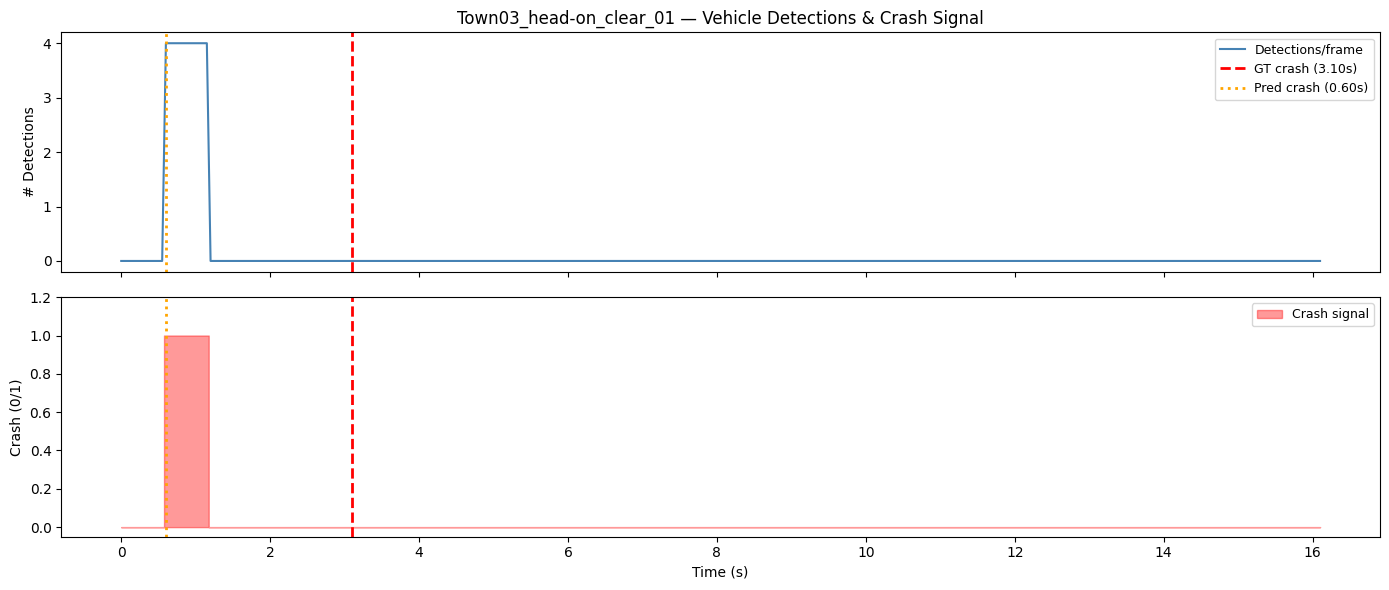

Timeline saved.


In [18]:
frames    = [r["frame_idx"] for r in frame_log]
times     = [f / FPS for f in frames]
n_dets    = [r["n_detections"] for r in frame_log]
is_crash  = [int(r["is_crash"]) for r in frame_log]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# ── Detections per frame ──────────────────────────────────────────────────────
axes[0].plot(times, n_dets, color="steelblue", lw=1.5, label="Detections/frame")
axes[0].axvline(gt_crash_time, color="red", ls="--", lw=2, label=f"GT crash ({gt_crash_time:.2f}s)")
if pred_crash_frame is not None:
    axes[0].axvline(pred_crash_frame / FPS, color="orange", ls=":", lw=2,
                    label=f"Pred crash ({pred_crash_frame/FPS:.2f}s)")
axes[0].set_ylabel("# Detections")
axes[0].legend(fontsize=9)
axes[0].set_title(f"{CLIP_NAME} — Vehicle Detections & Crash Signal")

# ── Crash signal ──────────────────────────────────────────────────────────────
axes[1].fill_between(times, is_crash, step="mid",
                     color="red", alpha=0.4, label="Crash signal")
axes[1].axvline(gt_crash_time, color="red", ls="--", lw=2)
if pred_crash_frame is not None:
    axes[1].axvline(pred_crash_frame / FPS, color="orange", ls=":", lw=2)
axes[1].set_ylabel("Crash (0/1)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylim(-0.05, 1.2)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{CLIP_NAME}_timeline.png", dpi=120)
plt.show()
print("Timeline saved.")

## 10. Preview Key Frames (Before / At / After Crash)

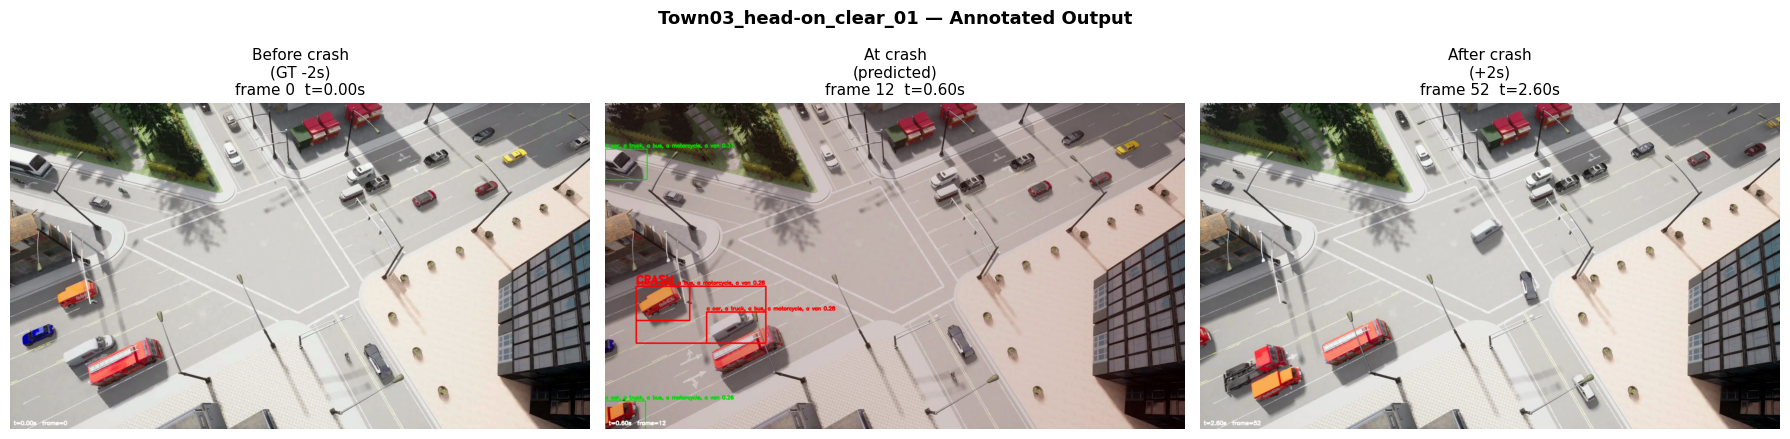

In [19]:
def read_frame(video_path: Path, frame_idx: int) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not read frame {frame_idx}")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


# Pick frames from the annotated output video
def read_annotated_frame(ann_video: Path, frame_idx: int) -> np.ndarray:
    cap = cv2.VideoCapture(str(ann_video))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) if ret else np.zeros((H, W, 3), dtype=np.uint8)


crash_f = pred_crash_frame if pred_crash_frame is not None else gt_crash_frame
preview_frames = {
    "Before crash\n(GT -2s)": max(0, crash_f - int(2 * FPS)),
    "At crash\n(predicted)": crash_f,
    "After crash\n(+2s)": min(NFRAMES - 1, crash_f + int(2 * FPS)),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, fidx) in zip(axes, preview_frames.items()):
    img = read_annotated_frame(output_path, fidx)
    ax.imshow(img)
    ax.set_title(f"{title}\nframe {fidx}  t={fidx/FPS:.2f}s", fontsize=11)
    ax.axis("off")

plt.suptitle(f"{CLIP_NAME} — Annotated Output", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"{CLIP_NAME}_preview.png", dpi=120)
plt.show()

## 11. Quick-Run on Multiple Clips (Batch Mode)

Run the same pipeline across several clips and aggregate scores.

In [ ]:
import pandas as pd

labels_df = pd.read_csv(SIM_DIR / "labels.csv")
print(f"Total clips in labels.csv: {len(labels_df)}")
labels_df.head(3)

In [ ]:
def process_clip(row: pd.Series, save_video: bool = False) -> dict:
    vid_path  = SIM_DIR / row["rgb_path"]
    ann_rel   = row["annotations_path"]

    ann_gz    = SIM_DIR / ann_rel
    clip_stem = Path(ann_rel).stem.replace(".json", "")
    ann_json  = ANNOT_DIR / f"{clip_stem}.json" / f"{clip_stem}.json"

    if ann_gz.exists():       ann = load_annotation(ann_gz)
    elif ann_json.exists():   ann = load_annotation(ann_json)
    else:                     return {"clip": clip_stem, "error": "annotation not found"}

    cap  = cv2.VideoCapture(str(vid_path))
    fps  = cap.get(cv2.CAP_PROP_FPS)
    w    = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h    = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    nf   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    sx   = w / INFER_SIZE[0]; sy = h / INFER_SIZE[1]

    gt_crash_iter = ann["collision"][0]["iteration"]
    ann_offset    = ann["base"][0]["iteration"]
    gt_frame      = gt_crash_iter - ann_offset
    gt_time       = gt_frame / fps
    (bx1, by1), (bx2, by2) = ann["collision"][0]["collision_bbox"]
    gt_cx, gt_cy  = ((bx1+bx2)/2)/w, ((by1+by2)/2)/h
    gt_type       = row["type"]

    if save_video:
        out_vid = OUTPUT_DIR / f"{clip_stem}_annotated.mp4"
        fourcc  = cv2.VideoWriter_fourcc(*"mp4v")
        vwriter = cv2.VideoWriter(str(out_vid), fourcc, fps, (w, h))

    clip_detector = FusedCrashDetector()
    last_boxes = np.zeros((0,4), dtype=np.float32); last_scores = np.zeros(0, dtype=np.float32)
    last_labels = []; last_masks = None
    pred_event = None

    for fi in range(nf):
        ret, frame_bgr = cap.read()
        if not ret: break

        if fi % DETECT_EVERY == 0:
            small   = cv2.resize(frame_bgr, INFER_SIZE, interpolation=cv2.INTER_AREA)
            pil_img = Image.fromarray(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
            result  = predict_multi(predictor, pil_img, VEHICLE_PROMPTS)
            if len(result.scores) > 0:
                boxes  = np.array(result.boxes, dtype=np.float32)
                scores = np.array(result.scores, dtype=np.float32)
                masks  = np.array(result.masks) if hasattr(result, "masks") and result.masks is not None else None
                labels = list(result.labels)
                boxes[:, [0,2]] *= sx; boxes[:, [1,3]] *= sy
                boxes, scores, masks = nms(boxes, scores, masks)
                labels = labels[:len(scores)]
                last_boxes, last_scores, last_labels, last_masks = boxes, scores, labels, masks
            else:
                last_boxes = np.zeros((0,4), dtype=np.float32); last_scores = np.zeros(0, dtype=np.float32)
                last_labels = []; last_masks = None

        event = clip_detector.process_frame(frame_bgr, fi, last_boxes, last_scores)
        if event is not None and pred_event is None:
            pred_event = event

        if save_video:
            active = clip_detector.get_tracks()
            is_cr  = event is not None or (pred_event and fi - pred_event.frame_idx < 60)
            cbox   = event.crash_box if event else (pred_event.crash_box if pred_event else None)
            ctype  = pred_event.collision_type if pred_event else "unknown"
            frm    = draw_frame(frame_bgr, last_boxes, last_scores, last_labels, last_masks,
                                active, is_cr, cbox, ctype, fi, fps)
            vwriter.write(frm)

    cap.release()
    if save_video: vwriter.release()

    if pred_event is not None:
        pred_time = pred_event.frame_idx / fps
        pred_cx   = ((pred_event.crash_box[0]+pred_event.crash_box[2])/2)/w
        pred_cy   = ((pred_event.crash_box[1]+pred_event.crash_box[3])/2)/h
        pred_type = pred_event.collision_type
    else:
        pred_time = nf / fps / 2; pred_cx, pred_cy = 0.5, 0.5; pred_type = "unknown"

    T  = temporal_score(pred_time, gt_time)
    S  = spatial_score(pred_cx, pred_cy, gt_cx, gt_cy)
    C  = 1.0 if pred_type == gt_type else 0.0
    HM = 3 / (1/T + 1/S + 1/max(C,1e-6)) if T > 0 and S > 0 else 0.0

    return {
        "clip": clip_stem, "type": row["type"], "pred_type": pred_type,
        "pred_time": round(pred_time,3), "gt_time": round(gt_time,3),
        "pred_cx": round(pred_cx,4), "pred_cy": round(pred_cy,4),
        "gt_cx": round(gt_cx,4), "gt_cy": round(gt_cy,4),
        "T": round(T,4), "S": round(S,4), "C": C, "HM": round(HM,4),
        "signals": pred_event.signals_triggered if pred_event else [],
    }


SAMPLE  = labels_df.sample(5, random_state=42)
results = []
for _, row in tqdm(SAMPLE.iterrows(), total=len(SAMPLE), desc="Clips"):
    r = process_clip(row, save_video=False)
    results.append(r)
    print(r)

results_df = pd.DataFrame(results)
print("\nMean scores:")
print(results_df[["T","S","C","HM"]].mean().round(4))
